<a href="https://colab.research.google.com/github/mayorga-py/alura_LATAM/blob/Challenge-Aura-Store/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [10]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("deep")
%matplotlib inline

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda['tienda'] = 'Tienda 1'
tienda2['tienda'] = 'Tienda 2'
tienda3['tienda'] = 'Tienda 3'
tienda4['tienda'] = 'Tienda 4'

# Combinar todos los datos en un único DataFrame
datos_completos = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


#1. Análisis de facturación



ANÁLISIS DE FACTURACIÓN TOTAL POR TIENDA
Facturación total por tienda:
tienda
Tienda 1    1.150880e+09
Tienda 2    1.116344e+09
Tienda 3    1.098020e+09
Tienda 4    1.038376e+09
Name: Precio, dtype: float64



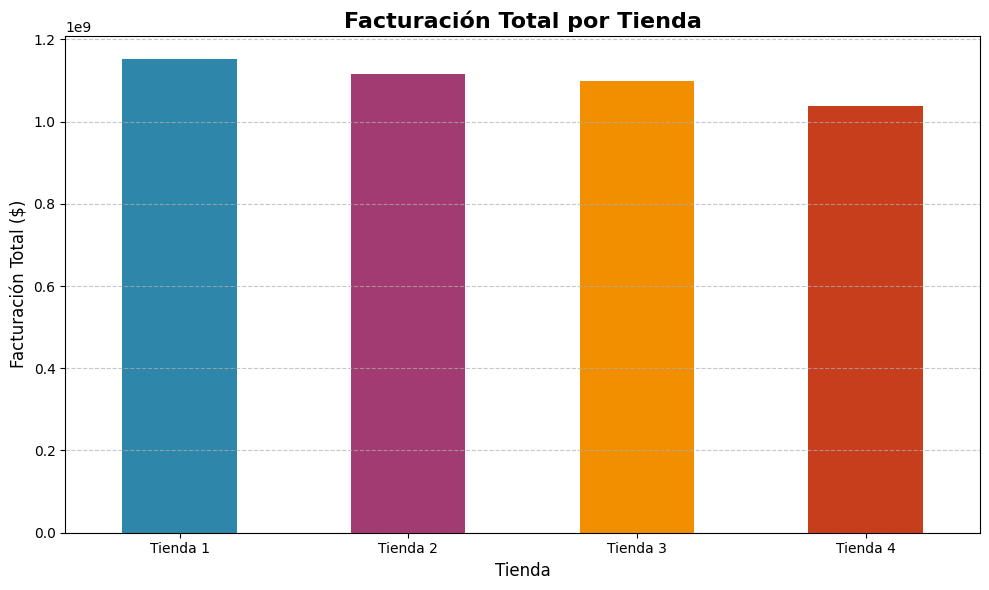

In [11]:
print("ANÁLISIS DE FACTURACIÓN TOTAL POR TIENDA")

# Calcular facturación total por tienda
facturacion_por_tienda = datos_completos.groupby('tienda')['Precio'].sum().sort_values(ascending=False)
print(f"Facturación total por tienda:\n{facturacion_por_tienda}\n")
# Visualización
plt.figure(figsize=(10, 6))
facturacion_por_tienda.plot(kind='bar', color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
plt.title('Facturación Total por Tienda', fontsize=16, fontweight='bold')
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Facturación Total ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 2. Ventas por categoría

In [3]:

ventas_categoria = data.groupby(["store", "product_category_name"])["order_item_id"].count().reset_index()
ventas_categoria = ventas_categoria.sort_values(["store", "order_item_id"], ascending=[True, False])

print("categorías más vendidas por tienda (Top 5 cada una):")
for tienda, df_tienda in ventas_categoria.groupby("store"):
    print(f"\n— {tienda} —")
    display(df_tienda.head(5))


NameError: name 'data' is not defined

# 3. Calificación promedio de la tienda


CATEGORÍAS MÁS POPULARES POR TIENDA
Categorías más populares por tienda (por cantidad de ventas):
Tienda 1: Muebles (465 ventas)
Tienda 2: Muebles (442 ventas)
Tienda 3: Muebles (499 ventas)
Tienda 4: Muebles (480 ventas)

Categorías más rentables por tienda (por facturación):
Tienda 1: Electrónicos ($429,493,500.00)
Tienda 2: Electrónicos ($410,831,100.00)
Tienda 3: Electrónicos ($410,775,800.00)
Tienda 4: Electrónicos ($409,476,100.00)


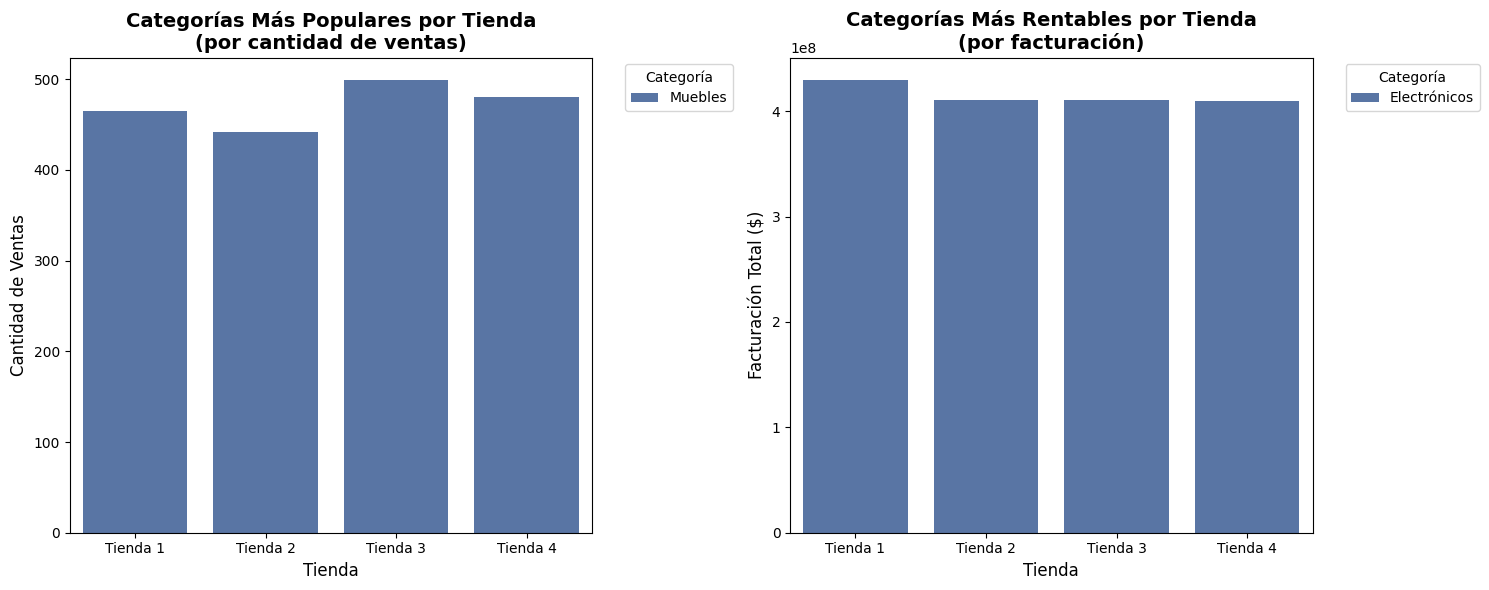

In [12]:
print("CATEGORÍAS MÁS POPULARES POR TIENDA")
categorias_populares = datos_completos.groupby(['tienda', 'Categoría del Producto']).size().reset_index(name='cantidad_ventas')
idx = categorias_populares.groupby('tienda')['cantidad_ventas'].idxmax()
categorias_mas_populares = categorias_populares.loc[idx]

print("Categorías más populares por tienda (por cantidad de ventas):")
for idx, row in categorias_mas_populares.iterrows():
    print(f"{row['tienda']}: {row['Categoría del Producto']} ({row['cantidad_ventas']} ventas)")
categorias_rentables = datos_completos.groupby(['tienda', 'Categoría del Producto'])['Precio'].sum().reset_index(name='facturacion')
idx = categorias_rentables.groupby('tienda')['facturacion'].idxmax()
categorias_mas_rentables = categorias_rentables.loc[idx]

print("\nCategorías más rentables por tienda (por facturación):")
for idx, row in categorias_mas_rentables.iterrows():
    print(f"{row['tienda']}: {row['Categoría del Producto']} (${row['facturacion']:,.2f})")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=categorias_mas_populares, x='tienda', y='cantidad_ventas', hue='Categoría del Producto', ax=ax1)
ax1.set_title('Categorías Más Populares por Tienda\n(por cantidad de ventas)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tienda', fontsize=12)
ax1.set_ylabel('Cantidad de Ventas', fontsize=12)
ax1.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.barplot(data=categorias_mas_rentables, x='tienda', y='facturacion', hue='Categoría del Producto', ax=ax2)
ax2.set_title('Categorías Más Rentables por Tienda\n(por facturación)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tienda', fontsize=12)
ax2.set_ylabel('Facturación Total ($)', fontsize=12)
ax2.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


# 4. Productos más y menos vendidos

PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA
Productos más vendidos por tienda (por cantidad):
Tienda 1: Armario (60 unidades)
Tienda 2: Iniciando en programación (65 unidades)
Tienda 3: Kit de bancas (57 unidades)
Tienda 4: Cama box (62 unidades)

Productos menos vendidos por tienda (entre los más populares):
Tienda 1: Armario (60 unidades)
Tienda 2: Iniciando en programación (65 unidades)
Tienda 3: Kit de bancas (57 unidades)
Tienda 4: Cama box (62 unidades)

Productos más rentables por tienda (por facturación):
Tienda 1: TV LED UHD 4K ($142,150,200.00)
Tienda 2: Iphone 15 ($113,225,800.00)
Tienda 3: Refrigerador ($99,889,700.00)
Tienda 4: Iphone 15 ($96,697,500.00)


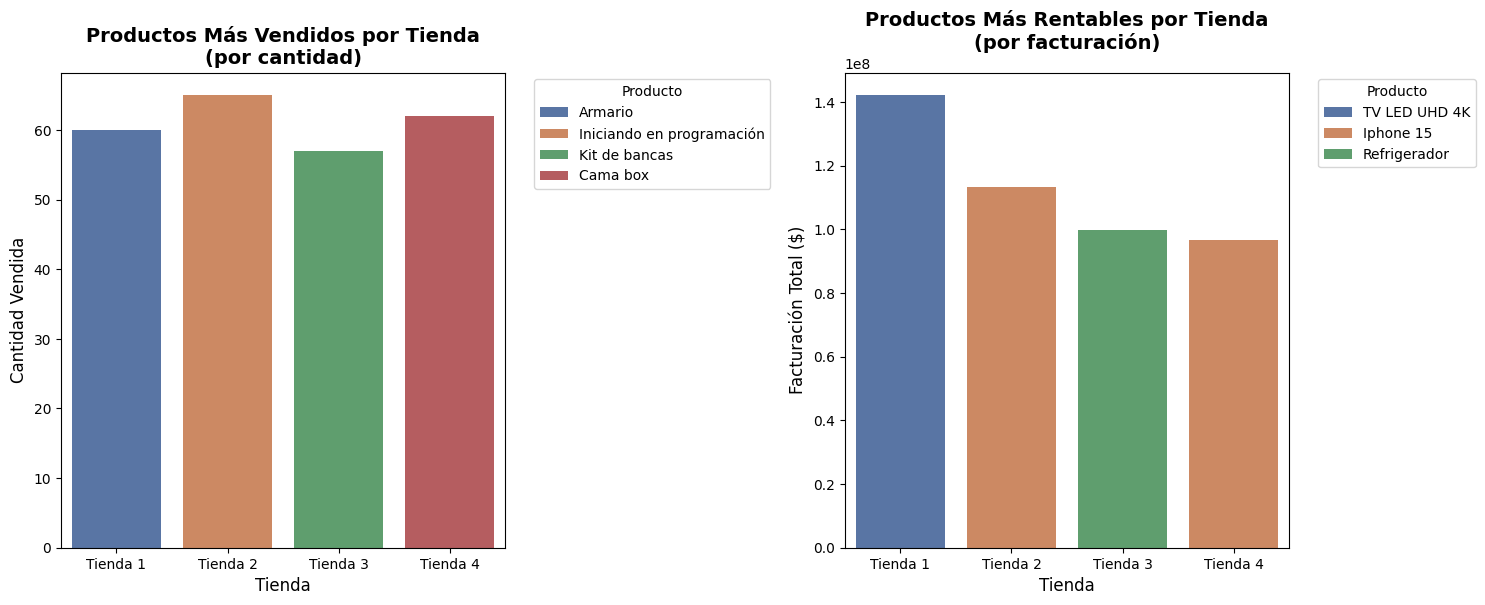

In [18]:
print("PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA")

productos_mas_vendidos = datos_completos.groupby(['tienda', 'Producto']).size().reset_index(name='cantidad')
idx = productos_mas_vendidos.groupby('tienda')['cantidad'].idxmax()
productos_mas_vendidos = productos_mas_vendidos.loc[idx]
print("Productos más vendidos por tienda (por cantidad):")
for idx, row in productos_mas_vendidos.iterrows():
    print(f"{row['tienda']}: {row['Producto']} ({row['cantidad']} unidades)")

idx = productos_mas_vendidos.groupby('tienda')['cantidad'].idxmin()
productos_menos_vendidos = productos_mas_vendidos.loc[idx]
print("\nProductos menos vendidos por tienda (entre los más populares):")
for idx, row in productos_menos_vendidos.iterrows():
    print(f"{row['tienda']}: {row['Producto']} ({row['cantidad']} unidades)")

productos_rentables = datos_completos.groupby(['tienda', 'Producto'])['Precio'].sum().reset_index(name='facturacion')
idx = productos_rentables.groupby('tienda')['facturacion'].idxmax()
productos_mas_rentables = productos_rentables.loc[idx]

print("\nProductos más rentables por tienda (por facturación):")
for idx, row in productos_mas_rentables.iterrows():
    print(f"{row['tienda']}: {row['Producto']} (${row['facturacion']:,.2f})")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=productos_mas_vendidos, x='tienda', y='cantidad', hue='Producto', ax=ax1)
ax1.set_title('Productos Más Vendidos por Tienda\n(por cantidad)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tienda', fontsize=12)
ax1.set_ylabel('Cantidad Vendida', fontsize=12)
ax1.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.barplot(data=productos_mas_rentables, x='tienda', y='facturacion', hue='Producto', ax=ax2)
ax2.set_title('Productos Más Rentables por Tienda\n(por facturación)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tienda', fontsize=12)
ax2.set_ylabel('Facturación Total ($)', fontsize=12)
ax2.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

COSTO PROMEDIO DE ENVÍO POR TIENDA
Costo promedio de envío por tienda:
tienda
Tienda 4    23459.46
Tienda 3    24805.68
Tienda 2    25216.24
Tienda 1    26018.61
Name: Costo de envío, dtype: float64

Costo total de envío por tienda:
tienda
Tienda 4    55317400.0
Tienda 3    58516600.0
Tienda 2    59485100.0
Tienda 1    61377900.0
Name: Costo de envío, dtype: float64

Ratio promedio de costo de envío vs precio por tienda:
tienda
Tienda 3    0.054
Tienda 1    0.055
Tienda 4    0.055
Tienda 2    0.056
Name: ratio_envio_precio, dtype: float64



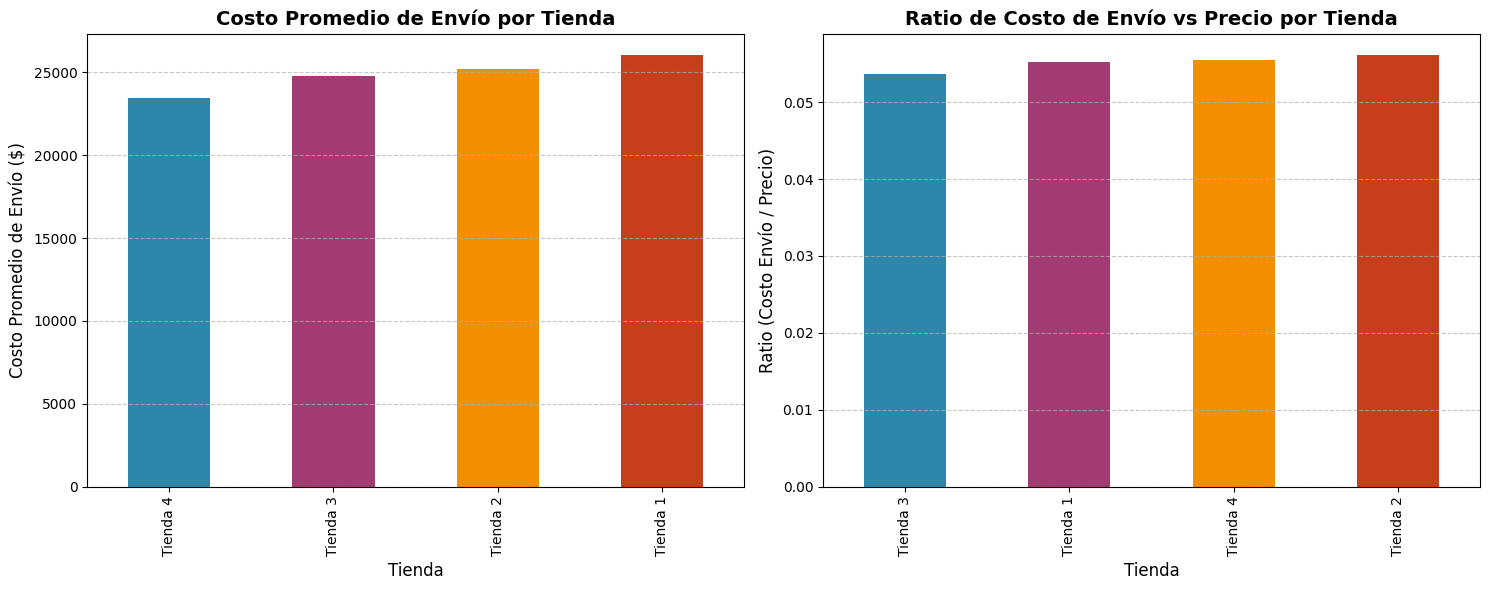

In [17]:
print("COSTO PROMEDIO DE ENVÍO POR TIENDA")

costo_envio_promedio = datos_completos.groupby('tienda')['Costo de envío'].mean().sort_values(ascending=True)
print(f"Costo promedio de envío por tienda:\n{costo_envio_promedio.round(2)}\n")
costo_envio_total = datos_completos.groupby('tienda')['Costo de envío'].sum().sort_values(ascending=True)
print(f"Costo total de envío por tienda:\n{costo_envio_total.round(2)}\n")
datos_completos['ratio_envio_precio'] = datos_completos['Costo de envío'] / datos_completos['Precio']
ratio_envio_promedio = datos_completos.groupby('tienda')['ratio_envio_precio'].mean().sort_values(ascending=True)
print(f"Ratio promedio de costo de envío vs precio por tienda:\n{ratio_envio_promedio.round(3)}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
costo_envio_promedio.plot(kind='bar', color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'], ax=ax1)
ax1.set_title('Costo Promedio de Envío por Tienda', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tienda', fontsize=12)
ax1.set_ylabel('Costo Promedio de Envío ($)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ratio_envio_promedio.plot(kind='bar', color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'], ax=ax2)
ax2.set_title('Ratio de Costo de Envío vs Precio por Tienda', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tienda', fontsize=12)
ax2.set_ylabel('Ratio (Costo Envío / Precio)', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
